# Mandalay Temperature Forecasting — Full Pipeline Walkthrough

**Purpose of this notebook:** a complete, runnable, step-by-step explanation of every stage of this project — from where the raw data came from, to how the model produces a next-day temperature prediction. Every code cell below is real, executable code (not simplified/pseudocode), matching what's actually in `train_parallel_fusion_attention.py` in this repository.

**Structure:**
1. Where the data comes from
2. Raw data inspection
3. Preprocessing — physical unit conversion
4. Resampling hourly → daily
5. Feature engineering (seasonality + lag features)
6. Train / validation / test split
7. Scaling (normalization)
8. Sequence windowing
9. Model architecture (LSTM → parallel attention → fusion → prediction)
10. Loading a trained model checkpoint
11. Making a real prediction, step by step
12. Evaluating on the full test set
13. Comparing all 6 models we tried
14. Summary — key talking points


## 1. Where the Data Comes From

The dataset is **ERA5 reanalysis data** — produced by the ECMWF (European Centre for Medium-Range Weather Forecasts). "Reanalysis" means it isn't a raw sensor reading; it's the output of a physics-based weather model that has been continuously corrected against millions of real historical observations (satellites, weather stations, balloons, ships) to produce the most physically-consistent estimate of what the atmosphere was actually doing, everywhere on Earth, going back decades.

**What we pulled:** hourly data for a single grid point over **Mandalay, Myanmar**, spanning **20 years**. The raw file contains these columns:

| Column | Meaning |
|---|---|
| `valid_time` | timestamp |
| `u10`, `v10` | wind velocity components at 10m height (east-west, north-south), m/s |
| `d2m` | dewpoint temperature at 2m, Kelvin |
| `t2m` | air temperature at 2m, Kelvin (**this is what we're forecasting**) |
| `msl` | mean sea-level pressure, Pa |
| `sp` | surface pressure, Pa |
| `tcc` | total cloud cover, fraction 0-1 |
| `tp` | total precipitation, meters |

Note everything is in raw physical/SI units (Kelvin, Pascals, meters) — the first thing we do is convert these into human-readable units.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
print("Libraries loaded. PyTorch version:", torch.__version__)

Libraries loaded. PyTorch version: 2.14.0+cu130


## 2. Raw Data Inspection

Let's load the raw CSV exactly as it comes, before touching anything.

In [2]:
df_raw = pd.read_csv("data/20years_dataset_mandalay.csv")
print("Shape:", df_raw.shape)
print("\nDate range:", df_raw['valid_time'].min(), "to", df_raw['valid_time'].max())
df_raw.head()

Shape: (180912, 11)

Date range: 2006-01-01 00:00:00 to 2026-08-21 23:00:00


,valid_time,u10,v10,d2m,t2m,msl,sp,tcc,tp,latitude,longitude
0,2006-01-01 00:00:00,0.037840,-0.357819,289.54108,289.54163,101793.810,100399.516,1.000000,0.0,22.0,96.0
1,2006-01-01 01:00:00,-0.010525,-0.312210,289.68518,289.68440,101860.375,100463.700,1.000000,0.0,22.0,96.0
2,2006-01-01 02:00:00,0.192518,-0.299515,290.22223,291.18488,101924.690,100527.625,1.000000,0.0,22.0,96.0
3,2006-01-01 03:00:00,0.441318,-0.361603,289.79102,292.17456,101926.810,100530.890,0.898010,0.0,22.0,96.0
4,2006-01-01 04:00:00,0.808121,-0.502777,290.23572,292.78384,101901.060,100510.330,0.777008,0.0,22.0,96.0


In [3]:
df_raw.describe()

,u10,v10,d2m,t2m,msl,sp,tcc,tp,latitude,longitude
count,180912.000000,180912.000000,180912.000000,180912.000000,180912.000000,180912.000000,180912.000000,180912.000000,180912.0,180912.0
mean,-0.371083,1.252905,294.109559,300.760004,100851.250191,99493.886199,0.512940,0.000118,22.0,96.0
std,0.972415,2.267154,4.080468,5.195263,453.147517,442.429959,0.417188,0.000514,0.0,0.0
min,-6.014069,-7.384933,271.891100,283.631770,99339.560000,98003.280000,0.000000,0.000000,22.0,96.0
25%,-1.081543,-0.537937,290.657100,298.179998,100500.875000,99151.667500,0.043488,0.000000,22.0,96.0
50%,-0.471519,0.883514,295.772250,301.062605,100830.000000,99475.707500,0.516174,0.000000,22.0,96.0
75%,0.368107,2.995140,297.428400,304.161035,101204.060000,99838.470000,0.975677,0.000017,22.0,96.0
max,6.006210,10.951981,301.773930,317.682400,102344.625000,100947.480000,1.000000,0.019888,22.0,96.0


## 3. Preprocessing Step 1 — Physical Unit Conversion

Raw ERA5 units are inconvenient for both humans and models to reason about. We convert:

- **Temperature**: Kelvin → Celsius, `T_C = T_K - 273.15`
- **Pressure**: Pascals → hectopascals (the unit used in every weather report), `hPa = Pa / 100`
- **Wind**: the two velocity *components* (`u10`, `v10`) are combined into a single wind **speed**: `speed = sqrt(u10² + v10²)`
- **Precipitation**: meters → millimeters (the standard rainfall unit), `mm = m × 1000`
- **Humidity**: ERA5 doesn't give relative humidity directly — we derive it from temperature and dewpoint using the **Magnus formula**, a standard meteorological approximation:

$$RH = 100 \times \frac{\exp\left(\frac{17.625 \cdot T_{dew}}{243.04 + T_{dew}}\right)}{\exp\left(\frac{17.625 \cdot T}{243.04 + T}\right)}$$

(Intuition: the closer the dewpoint is to the actual temperature, the more saturated — humid — the air is.)

In [4]:
df = df_raw.rename(columns={
    "valid_time": "date", "u10": "wind_u_10m", "v10": "wind_v_10m",
    "d2m": "dewpoint_2m", "t2m": "temperature_2m", "msl": "sea_level_pressure",
    "sp": "surface_pressure", "tcc": "total_cloud_cover", "tp": "total_precipitation",
})
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df["temperature_c"] = df["temperature_2m"] - 273.15
df["dewpoint_c"] = df["dewpoint_2m"] - 273.15
df["surface_pressure_hpa"] = df["surface_pressure"] / 100
df["wind_speed_10m"] = np.sqrt(df["wind_u_10m"] ** 2 + df["wind_v_10m"] ** 2)
df["precipitation_mm"] = df["total_precipitation"] * 1000
df["humidity"] = 100 * (
    np.exp((17.625 * df["dewpoint_c"]) / (243.04 + df["dewpoint_c"]))
    / np.exp((17.625 * df["temperature_c"]) / (243.04 + df["temperature_c"]))
).clip(0, 100)

print("Before -> After, first row:")
print(f"  Temperature: {df_raw['t2m'].iloc[0]:.2f} K  ->  {df['temperature_c'].iloc[0]:.2f} C")
print(f"  Pressure:    {df_raw['sp'].iloc[0]:.1f} Pa  ->  {df['surface_pressure_hpa'].iloc[0]:.2f} hPa")
print(f"  Wind:        u={df_raw['u10'].iloc[0]:.2f}, v={df_raw['v10'].iloc[0]:.2f}  ->  speed={df['wind_speed_10m'].iloc[0]:.2f} m/s")
print(f"  Humidity (derived): {df['humidity'].iloc[0]:.1f}%")

Before -> After, first row:
  Temperature: 289.54 K  ->  16.39 C
  Pressure:    100399.5 Pa  ->  1004.00 hPa
  Wind:        u=0.04, v=-0.36  ->  speed=0.36 m/s
  Humidity (derived): 100.0%


## 4. Preprocessing Step 2 — Resample Hourly → Daily

We forecast **next-day** temperature, so hourly resolution is finer than we need — daily aggregates are both sufficient and much less noisy. We use **mean** for most variables (average conditions across the day) and **sum** for precipitation (total rainfall for the day, not an average — an average would understate a single heavy storm).

In [5]:
daily = df.set_index("date").resample("D").agg({
    "temperature_c": "mean", "dewpoint_c": "mean", "humidity": "mean",
    "precipitation_mm": "sum", "wind_speed_10m": "mean",
    "total_cloud_cover": "mean", "surface_pressure_hpa": "mean",
}).dropna()

print("Hourly rows:", len(df), " ->  Daily rows:", len(daily))
daily.head()

Hourly rows: 180912  ->  Daily rows: 7538


,temperature_c,dewpoint_c,humidity,precipitation_mm,wind_speed_10m,total_cloud_cover,surface_pressure_hpa
date,,,,,,,
2006-01-01,19.849811,17.024408,84.753893,0.000000,1.280445,0.739168,1002.547223
2006-01-02,19.575222,16.717523,84.691854,0.002861,1.213346,0.857658,1001.024258
2006-01-03,18.543229,15.911028,85.889535,0.000000,1.296804,0.677745,999.651740
2006-01-04,18.070170,15.042616,84.254552,0.013828,1.118573,0.398137,998.552651
2006-01-05,18.958599,15.002506,79.502967,0.002384,1.182876,0.497737,998.791254


## 5. Preprocessing Step 3 — Feature Engineering

Two kinds of engineered features are added:

**A. Seasonality (cyclical encoding).** Simply using "month = 1, 2, ... 12" is misleading to a model — December (12) and January (1) are numerically far apart but are actually adjacent seasons. We fix this with **sine/cosine encoding**, which wraps the calendar into a circle so December and January end up close together in the encoded space:

$$\sin\left(\frac{2\pi \cdot \text{month}}{12}\right), \quad \cos\left(\frac{2\pi \cdot \text{month}}{12}\right)$$

Same idea applied to day-of-year, for finer-grained seasonal position.

**B. Autoregressive lag features.** We explicitly give the model yesterday's, 2-days-ago's, 3-days-ago's, and a week-ago's values for temperature (and 1-day-ago for humidity/pressure/rain) as extra input columns. The LSTM *could* learn these relationships on its own from the raw sequence, but handing them over directly makes the recent past easier for the model to use, especially the very strong day-to-day persistence signal in temperature.

In [6]:
daily["month"] = daily.index.month
daily["day_of_year"] = daily.index.dayofyear
daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)
daily["day_sin"] = np.sin(2 * np.pi * daily["day_of_year"] / 365.25)
daily["day_cos"] = np.cos(2 * np.pi * daily["day_of_year"] / 365.25)
for lag in [1, 2, 3, 7]:
    daily[f"temp_lag_{lag}"] = daily["temperature_c"].shift(lag)
daily["humidity_lag_1"] = daily["humidity"].shift(1)
daily["pressure_lag_1"] = daily["surface_pressure_hpa"].shift(1)
daily["rain_lag_1"] = daily["precipitation_mm"].shift(1)
daily = daily.dropna()  # first 7 rows lose their lag_7 value - drop them

feature_columns = [
    "temperature_c", "dewpoint_c", "humidity", "precipitation_mm",
    "wind_speed_10m", "total_cloud_cover", "surface_pressure_hpa",
    "month_sin", "month_cos", "day_sin", "day_cos",
    "temp_lag_1", "temp_lag_2", "temp_lag_3", "temp_lag_7",
    "humidity_lag_1", "pressure_lag_1", "rain_lag_1",
]
target_column = "temperature_c"

print(f"{len(feature_columns)} input features, final daily row count: {len(daily)}")
daily[feature_columns].head()

18 input features, final daily row count: 7531


,temperature_c,dewpoint_c,humidity,precipitation_mm,wind_speed_10m,total_cloud_cover,surface_pressure_hpa,month_sin,month_cos,day_sin,day_cos,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_7,humidity_lag_1,pressure_lag_1,rain_lag_1
date,,,,,,,,,,,,,,,,,,
2006-01-08,20.573203,17.061881,81.785917,0.000000,0.986236,0.539303,999.434052,0.5,0.866025,0.137185,0.990545,20.592453,19.918817,18.958599,19.849811,83.020674,999.944582,0.0
2006-01-09,20.921843,16.751333,79.298385,0.000000,1.039647,0.036254,999.743906,0.5,0.866025,0.154204,0.988039,20.573203,20.592453,19.918817,19.575222,81.785917,999.434052,0.0
2006-01-10,21.164278,17.044181,79.328314,0.000000,1.316676,0.076422,999.006302,0.5,0.866025,0.171177,0.985240,20.921843,20.573203,20.592453,18.543229,79.298385,999.743906,0.0
2006-01-11,19.957369,16.547065,82.466383,0.000000,1.213588,0.115545,998.698158,0.5,0.866025,0.188099,0.982150,21.164278,20.921843,20.573203,18.070170,79.328314,999.006302,0.0
2006-01-12,20.242227,17.009584,83.174478,0.000477,1.330539,0.040311,998.557556,0.5,0.866025,0.204966,0.978769,19.957369,21.164278,20.921843,18.958599,82.466383,998.698158,0.0


## 6. Train / Validation / Test Split — Chronological, Not Random

This is important: we **never shuffle** time-series data before splitting. If we randomly shuffled and split, the model could end up training on a day that comes *after* a test day chronologically — effectively letting it "see the future" during training, which is data leakage and would make our evaluation numbers meaningless.

Instead we cut along the calendar:
- **Train**: everything through 2021
- **Validation**: 2022–2023 (used to decide when to stop training / pick the best checkpoint)
- **Test**: 2024 onward (the model never sees this during training or model selection — this is the only number we trust as "real" performance)

In [7]:
train = daily.loc[:"2021-12-31"]
val = daily.loc["2022-01-01":"2023-12-31"]
test = daily.loc["2024-01-01":]

print(f"Train: {len(train):>5} days  ({train.index.min().date()} to {train.index.max().date()})")
print(f"Val:   {len(val):>5} days  ({val.index.min().date()} to {val.index.max().date()})")
print(f"Test:  {len(test):>5} days  ({test.index.min().date()} to {test.index.max().date()})")

Train:  5837 days  (2006-01-08 to 2021-12-31)
Val:     730 days  (2022-01-01 to 2023-12-31)
Test:    964 days  (2024-01-01 to 2026-08-21)


## 7. Scaling (Normalization)

Neural networks train much better when input features are on similar numeric scales — otherwise a feature like pressure (~1013) can numerically dominate a feature like cloud cover (0–1) even if cloud cover is just as important. We use **MinMax scaling**, which maps every feature into the [0, 1] range.

**Critical detail:** the scaler is `fit()` on the **training set only**, then just `transform()`-applied to validation/test. If we fit on the full dataset (including test), statistics from the future (e.g. the test set's exact min/max) would leak into how we scale the training data — another, subtler form of data leakage.

In [8]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(train[feature_columns])
X_val_scaled = feature_scaler.transform(val[feature_columns])
X_test_scaled = feature_scaler.transform(test[feature_columns])

y_train_scaled = target_scaler.fit_transform(train[[target_column]])
y_val_scaled = target_scaler.transform(val[[target_column]])
y_test_scaled = target_scaler.transform(test[[target_column]])

print("Scaled feature range (train):", X_train_scaled.min().round(3), "to", X_train_scaled.max().round(3))
print("(target_scaler is kept separately so we can convert predictions back to real Celsius later)")

Scaled feature range (train): 0.0 to 1.0
(target_scaler is kept separately so we can convert predictions back to real Celsius later)


## 8. Sequence Windowing — Turning a Table into (Input, Target) Pairs

The model needs to see a **window of past days** to predict the next one. We use a **30-day sliding window**: for every day `i` in the dataset, the input is the 30 days *before* it (all 18 features, for each of those 30 days), and the target is the actual temperature on day `i` itself.

So one training example has shape `(30, 18)` — 30 timesteps, 18 features each — and one target value.

In [9]:
def create_sequences(X, y, sequence_length):
    X_seq, y_seq = [], []
    for i in range(sequence_length, len(X)):
        X_seq.append(X[i - sequence_length:i])
        y_seq.append(y[i])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

SEQUENCE_LENGTH = 30
X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)
X_val, y_val = create_sequences(X_val_scaled, y_val_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, SEQUENCE_LENGTH)

print("X_train shape:", X_train.shape, " (examples, timesteps, features)")
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (5807, 30, 18)  (examples, timesteps, features)
X_val shape:   (700, 30, 18)
X_test shape:  (934, 30, 18)


## 9. Model Architecture — LSTM → Parallel Attention → Fusion → Prediction

Now the model itself. In plain language, in order:

**LSTM.** Reads the 30-day sequence one day at a time, keeping a running internal summary ("hidden state") that gets updated at each step. By the end, it has produced a hidden-state vector *for every one of the 30 days*, each one summarizing "everything relevant up to and including this day."

**Two attention mechanisms, run in parallel** (both reading the LSTM's output independently — neither feeds into the other):

- **Feature Attention** — at each of the 30 timesteps, decides which of the LSTM's internal signals (its 64 hidden units) matter most, then averages over time into one summary vector. Answers: *"which learned patterns matter?"*
- **Temporal Attention** — decides which of the 30 *days* matter most for tomorrow's prediction (a big storm 3 days ago might matter more than a calm day 20 days ago). Answers: *"which days matter?"*

**Fusion.** Combines the two attention outputs into one vector. We tested 4 different ways to do this (see Section 13) — the code below shows all 4, controlled by the `fusion` argument.

**Prediction head.** A small feed-forward network (Dense → ReLU → Dropout → Dense) turns the fused vector into a single number: tomorrow's predicted temperature (scaled; converted back to Celsius afterward).

In [10]:
class FeatureAttention(nn.Module):
    """Softmax attention over the LSTM's hidden channels, computed
    independently at each timestep, then mean-pooled over time."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, hidden_dim)
        nn.init.zeros_(self.score.weight)  # start uniform, not randomly skewed
        nn.init.zeros_(self.score.bias)

    def forward(self, h):
        scores = torch.tanh(self.score(h))
        weights = torch.softmax(scores, dim=-1)
        pooled = torch.mean(h * weights, dim=1)
        return pooled, weights


class TemporalAttention(nn.Module):
    """Bahdanau-style additive attention over the 30 timesteps."""
    def __init__(self, hidden_dim, units=32):
        super().__init__()
        self.W = nn.Linear(hidden_dim, units)
        self.V = nn.Linear(units, 1)
        nn.init.zeros_(self.V.weight)
        nn.init.zeros_(self.V.bias)

    def forward(self, h):
        score = self.V(torch.tanh(self.W(h)))
        weights = torch.softmax(score, dim=1)
        context = torch.sum(weights * h, dim=1)
        return context, weights


class AdaptiveFusion(nn.Module):
    """Learned gate: a small network decides the blend from the CONTENT
    of the two attention vectors. 128 learned parameters."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)
        nn.init.zeros_(self.gate.weight)
        nn.init.zeros_(self.gate.bias)

    def forward(self, v_feat, v_temp):
        gate = torch.sigmoid(self.gate(torch.cat([v_feat, v_temp], dim=-1)))
        fused = gate * v_feat + (1 - gate) * v_temp
        return fused, gate


class GlobalScalarFusion(nn.Module):
    """A single learned scalar mixing ratio, shared by every example.
    Just 1 learned parameter."""
    def __init__(self):
        super().__init__()
        self.raw_alpha = nn.Parameter(torch.zeros(1))

    def forward(self, v_feat, v_temp):
        alpha = torch.sigmoid(self.raw_alpha)
        fused = alpha * v_feat + (1 - alpha) * v_temp
        return fused, alpha


def confidence_fusion(v_feat, v_temp, feat_weights, temp_weights):
    """Parameter-free: blend weight = which attention mechanism is more
    'confident' (lower entropy = more peaked = more trusted)."""
    eps = 1e-8
    hidden_dim = feat_weights.shape[-1]
    seq_len = temp_weights.shape[1]
    feat_entropy = -(feat_weights * torch.log(feat_weights + eps)).sum(dim=-1)
    feat_entropy = feat_entropy.mean(dim=1) / np.log(hidden_dim)
    temp_w = temp_weights.squeeze(-1)
    temp_entropy = -(temp_w * torch.log(temp_w + eps)).sum(dim=1) / np.log(seq_len)
    gate = torch.softmax(torch.stack([-feat_entropy, -temp_entropy], dim=-1), dim=-1)
    g_feat = gate[:, 0:1]
    fused = g_feat * v_feat + (1 - g_feat) * v_temp
    return fused, g_feat


class ParallelFusionDualAttentionLSTM(nn.Module):
    def __init__(self, n_features, lstm_units=64, temp_att_units=32, fusion="average"):
        super().__init__()
        self.fusion_mode = fusion
        self.lstm = nn.LSTM(n_features, lstm_units, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.feature_attention = FeatureAttention(lstm_units)
        self.temporal_attention = TemporalAttention(lstm_units, temp_att_units)
        if fusion == "adaptive":
            self.fusion = AdaptiveFusion(lstm_units)
        elif fusion == "global_scalar":
            self.fusion = GlobalScalarFusion()
        else:
            self.fusion = None
        self.dense1 = nn.Linear(lstm_units, 16)
        self.dropout2 = nn.Dropout(0.2)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout1(lstm_out)
        v_feat, feat_weights = self.feature_attention(lstm_out)
        v_temp, temp_weights = self.temporal_attention(lstm_out)
        if self.fusion_mode in ("adaptive", "global_scalar"):
            fused, gate = self.fusion(v_feat, v_temp)
        elif self.fusion_mode == "confidence":
            fused, gate = confidence_fusion(v_feat, v_temp, feat_weights, temp_weights)
        else:
            fused = (v_feat + v_temp) / 2
            gate = None
        h = torch.relu(self.dense1(fused))
        h = self.dropout2(h)
        output = self.output_layer(h)
        return output, feat_weights, temp_weights, gate

print("Model classes defined.")

Model classes defined.


## 10. Loading Our Trained Model

Training this for real (100 epochs, early stopping) takes long enough that we did it ahead of time on GPU hardware, not live in this notebook. Here we load the actual saved weights from that training run — this is our **best-performing model overall**: parallel fusion with the `average` combination rule, seed 1.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

n_features = X_train.shape[2]
model = ParallelFusionDualAttentionLSTM(n_features, fusion="average").to(device)
model.load_state_dict(torch.load("models/parallel_fusion_average_seed1.pt", map_location=device))
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded checkpoint. Total model parameters: {n_params:,}")

Running on: cpu
Loaded checkpoint. Total model parameters: 28,834


## 11. Making a Real Prediction, Step by Step

Let's pick one specific day from the test set and walk through exactly what the model does:

1. Take the 30 days *before* that date (already scaled, already windowed — this is one row of `X_test`)
2. Feed it through the model
3. The model outputs a number in the *scaled* [0, 1] space
4. Convert that back to real Celsius using `target_scaler.inverse_transform`
5. Compare against what the temperature *actually* was, and against the naive guess ("tomorrow = same as today")

In [12]:
example_idx = 100  # an arbitrary day in the test set

x_example = torch.from_numpy(X_test[example_idx:example_idx+1]).to(device)
with torch.no_grad():
    pred_scaled, feat_w, temp_w, gate = model(x_example)
pred_scaled = pred_scaled.cpu().numpy()

predicted_c = target_scaler.inverse_transform(pred_scaled)[0, 0]
actual_c = target_scaler.inverse_transform(y_test[example_idx:example_idx+1])[0, 0]
naive_c = target_scaler.inverse_transform(X_test[example_idx:example_idx+1, -1, 0].reshape(-1, 1))[0, 0]

test_dates = test.index[SEQUENCE_LENGTH:]
print(f"Predicting for: {test_dates[example_idx].date()}")
print(f"  Actual temperature tomorrow:         {actual_c:.2f} C")
print(f"  Model prediction:                    {predicted_c:.2f} C   (error: {abs(actual_c - predicted_c):.2f} C)")
print(f"  Naive guess (same as today):         {naive_c:.2f} C   (error: {abs(actual_c - naive_c):.2f} C)")

Predicting for: 2024-05-10
  Actual temperature tomorrow:         30.99 C
  Model prediction:                    31.37 C   (error: 0.39 C)
  Naive guess (same as today):         31.65 C   (error: 0.66 C)


We can also look at the temporal attention weights for this specific prediction — which of the 30 past days did the model actually focus on?

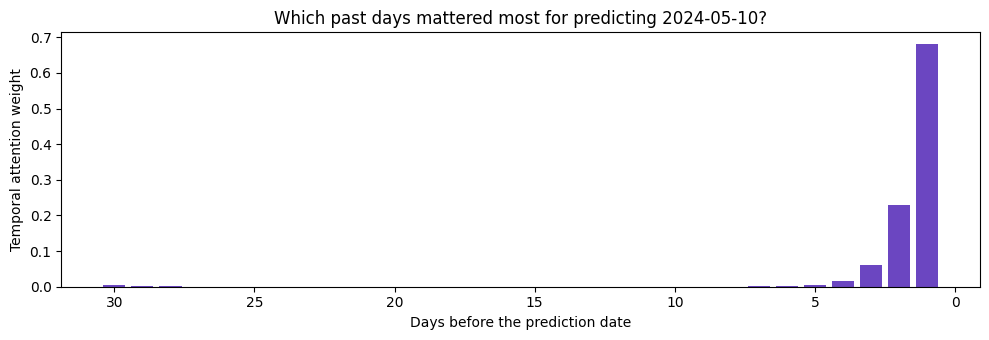

Most-attended day: 1 day(s) before the prediction date


In [13]:
temp_weights_np = temp_w[0].cpu().numpy().flatten()  # (30,)
days_ago = np.arange(30, 0, -1)

plt.figure(figsize=(10, 3.5))
plt.bar(days_ago, temp_weights_np, color="#6B46C1")
plt.gca().invert_xaxis()
plt.xlabel("Days before the prediction date")
plt.ylabel("Temporal attention weight")
plt.title(f"Which past days mattered most for predicting {test_dates[example_idx].date()}?")
plt.tight_layout()
plt.savefig("attention_example.png", dpi=120)
plt.show()
print(f"Most-attended day: {days_ago[temp_weights_np.argmax()]} day(s) before the prediction date")

## 12. Evaluating on the Full Test Set

One example is illustrative, but the real evaluation uses **every single test-set day** (2024 onward, ~934 examples), comparing against the **naive baseline** — simply guessing "tomorrow = same as today," which is a genuinely strong baseline for day-ahead temperature and non-trivial to beat.

In [14]:
model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test).to(device)
    pred_scaled_all, _, _, _ = model(X_test_t)
    pred_scaled_all = pred_scaled_all.cpu().numpy()

pred_c_all = target_scaler.inverse_transform(pred_scaled_all)
true_c_all = target_scaler.inverse_transform(y_test)
naive_c_all = target_scaler.inverse_transform(X_test[:, -1, 0].reshape(-1, 1))

model_mae = mean_absolute_error(true_c_all, pred_c_all)
model_rmse = np.sqrt(mean_squared_error(true_c_all, pred_c_all))
naive_mae = mean_absolute_error(true_c_all, naive_c_all)
naive_rmse = np.sqrt(mean_squared_error(true_c_all, naive_c_all))

print(f"{'Model':<20} {'MAE (C)':<10} {'RMSE (C)'}")
print("-" * 40)
print(f"{'Naive baseline':<20} {naive_mae:<10.3f} {naive_rmse:.3f}")
print(f"{'Parallel (average)':<20} {model_mae:<10.3f} {model_rmse:.3f}")
print(f"\nThis single seed beats naive baseline by {naive_mae - model_mae:.3f} C MAE")

Model                MAE (C)    RMSE (C)
----------------------------------------
Naive baseline       0.674      0.907
Parallel (average)   0.613      0.814

This single seed beats naive baseline by 0.061 C MAE


Let's also visualize predicted vs. actual over a slice of the test period, so we can see the model's behavior over time rather than just one summary number.

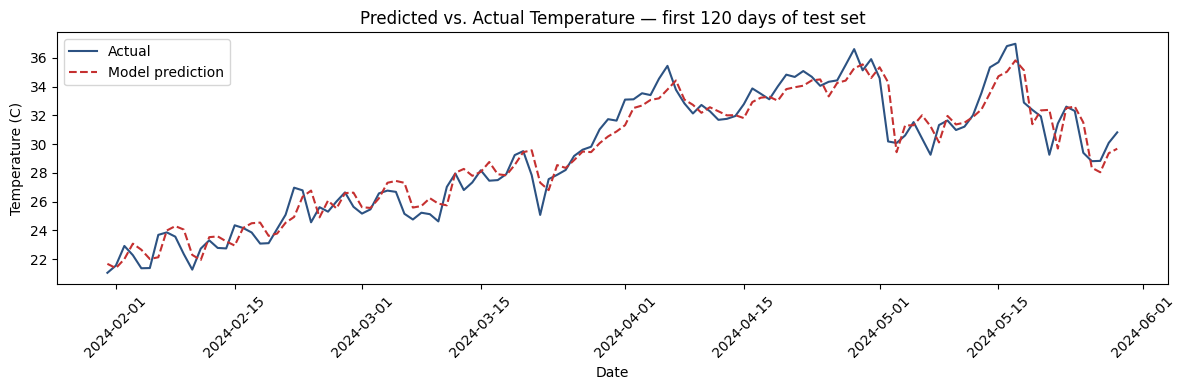

In [15]:
plot_start, plot_len = 0, 120
dates_slice = test_dates[plot_start:plot_start+plot_len]

plt.figure(figsize=(12, 4))
plt.plot(dates_slice, true_c_all[plot_start:plot_start+plot_len], label="Actual", color="#2C5282", linewidth=1.5)
plt.plot(dates_slice, pred_c_all[plot_start:plot_start+plot_len], label="Model prediction", color="#C53030", linewidth=1.5, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.title("Predicted vs. Actual Temperature — first 120 days of test set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=120)
plt.show()

## 13. Comparing All 6 Models We Tried

This project tested six architectures total, each evaluated over **5 random seeds** (not just one run — a single seed can get lucky or unlucky, so we report the mean and standard deviation across 5 independent training runs). These numbers come from `results.jsonl` in this repository, produced by actually running each training script.

**Two sequential architectures** (feature+temporal attention applied one after another):
- `feature_first`: Input → Feature Attention → LSTM → Temporal Attention
- `lstm_first`: Input → LSTM → Feature Attention → Temporal Attention

**Four parallel-fusion architectures** (both attention types computed independently, then combined):
- `average` — fixed 50/50 blend, 0 learned parameters
- `confidence` — entropy-based confidence gate, 0 learned parameters
- `global_scalar` — one learned mixing ratio, 1 parameter
- `adaptive` — a full learned gate network, 128 parameters

In [16]:
import json

with open("results.jsonl") as f:
    all_results = [json.loads(line) for line in f if line.strip()]

df_results = pd.DataFrame(all_results)
summary = df_results.groupby("model")["mae"].agg(["mean", "std", "count"]).sort_values("mean")
summary.columns = ["MAE mean", "MAE std", "n_seeds"]
print(summary.round(3))

                                     MAE mean  MAE std  n_seeds
model                                                          
parallel_fusion_average_torch           0.613    0.003        5
parallel_fusion_confidence_torch        0.618    0.003        5
parallel_fusion_global_scalar_torch     0.623    0.017        5
parallel_fusion_adaptive_torch          0.638    0.025        5
lstm_first_torch                        0.659    0.018        5
feature_first_torch                     0.700    0.187        5


### The key finding: fusion complexity vs. accuracy and stability

Lining these up by how many learned parameters the fusion step has reveals a clean pattern — and this is the actual empirical finding of the project, not any single model "winning."


                                     fusion_params  MAE mean  MAE std
model                                                                
parallel_fusion_average_torch                    0    0.6129   0.0028
parallel_fusion_confidence_torch                 0    0.6176   0.0034
parallel_fusion_global_scalar_torch              1    0.6231   0.0170
parallel_fusion_adaptive_torch                 128    0.6377   0.0248


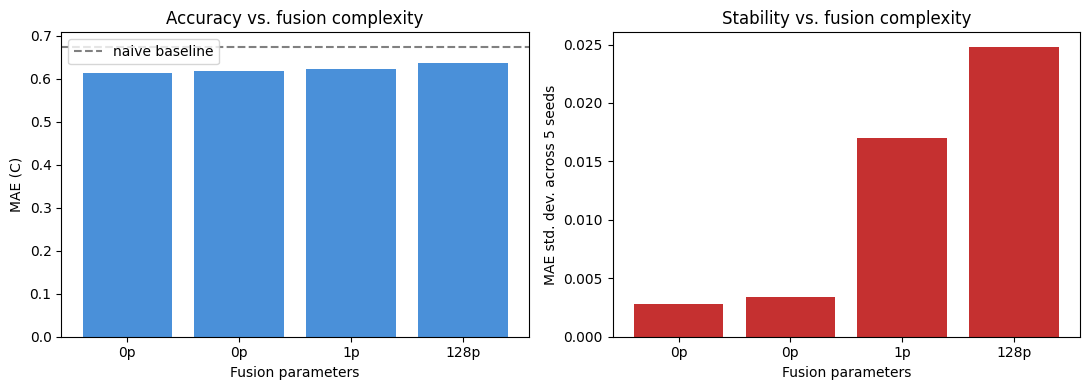

In [17]:
param_counts = {
    "parallel_fusion_average_torch": 0,
    "parallel_fusion_confidence_torch": 0,
    "parallel_fusion_global_scalar_torch": 1,
    "parallel_fusion_adaptive_torch": 128,
}

fusion_summary = summary.loc[summary.index.isin(param_counts.keys())].copy()
fusion_summary["fusion_params"] = [param_counts[m] for m in fusion_summary.index]
fusion_summary = fusion_summary.sort_values("fusion_params")
print(fusion_summary[["fusion_params", "MAE mean", "MAE std"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(len(fusion_summary)), fusion_summary["MAE mean"], color="#4A90D9")
axes[0].set_xticks(range(len(fusion_summary)))
axes[0].set_xticklabels([f"{p}p" for p in fusion_summary["fusion_params"]])
axes[0].set_xlabel("Fusion parameters")
axes[0].set_ylabel("MAE (C)")
axes[0].set_title("Accuracy vs. fusion complexity")
axes[0].axhline(naive_mae, color="gray", linestyle="--", label="naive baseline")
axes[0].legend()

axes[1].bar(range(len(fusion_summary)), fusion_summary["MAE std"], color="#C53030")
axes[1].set_xticks(range(len(fusion_summary)))
axes[1].set_xticklabels([f"{p}p" for p in fusion_summary["fusion_params"]])
axes[1].set_xlabel("Fusion parameters")
axes[1].set_ylabel("MAE std. dev. across 5 seeds")
axes[1].set_title("Stability vs. fusion complexity")

plt.tight_layout()
plt.savefig("complexity_staircase.png", dpi=120)
plt.show()

## 14. Summary — Talking Points for Tomorrow

**The pipeline, in one sentence per step:**
1. Raw hourly ERA5 reanalysis data for Mandalay (20 years) →
2. convert to physical units (°C, hPa, m/s, mm, %) →
3. resample to daily →
4. add seasonality (cyclical sin/cos) and lag features →
5. split chronologically into train/val/test (no shuffling, no leakage) →
6. scale to [0,1] (fit on train only) →
7. window into 30-day sequences →
8. LSTM → parallel Feature Attention + Temporal Attention → Fusion → prediction

**What we found:**
- The best model (`average` fusion) reaches **MAE 0.613 ± 0.002 °C**, reliably beating the naive "same as yesterday" baseline (0.674 °C) on all 5 seeds
- **The core finding is a complexity staircase**: as the fusion step gets more learnable parameters (0 → 0 → 1 → 128), accuracy gets *worse* and cross-seed variance gets *worse*, monotonically, with no exceptions
- We checked the literature: parallel dual-attention fusion itself is not new (traces to RETAIN, 2016), and entropy-based confidence gating isn't new either (recent papers in other domains use nearly the same formula) — so the contribution isn't a new architecture
- What does appear genuinely new: (1) this specific complexity-vs-stability pattern, demonstrated with a controlled 4-point comparison, and (2) as far as we found, **no prior ML/deep-learning weather forecasting study exists for Myanmar** at all

**Honest limitations to mention proactively:**
- `feature_first` has an unresolved unstable seed (bimodal — one of 5 runs diverges badly)
- Single location (Mandalay), single-day-ahead horizon only
- Improvements over naive baseline are real but modest in absolute terms
